In [ ]:
# FEATURE DISCOVERY

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression
)


In [ ]:
# Load data

df = pd.read_csv("C:/Users/josue/Desktop/Universidad/KAGGLE/Feature-Engineering/datasets/House_Prices/house_prices.csv")

TARGET = "price"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Shape:", df.shape)
X.head()


Shape: (21613, 21)


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,3,1.00,1180,5650,1.0,N,0,Average,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,N,0,Average,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,N,0,Average,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,N,0,Very Good,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,N,0,Average,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# 1. Correlation Analysis

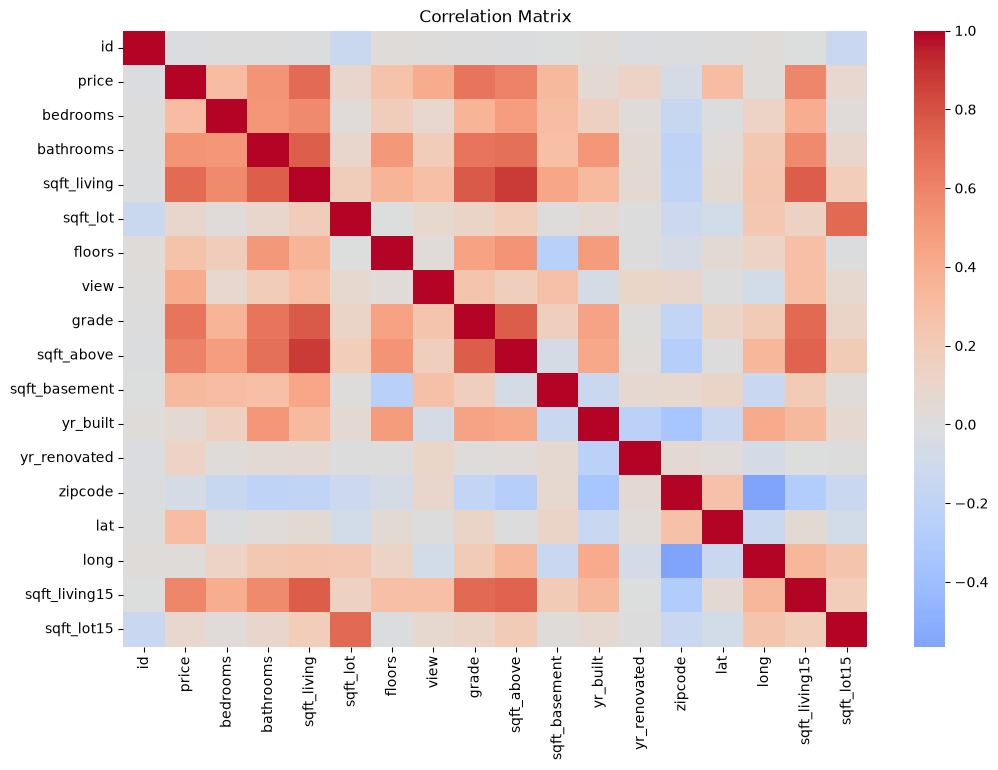

In [7]:
# CORRELATION MATRIX

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

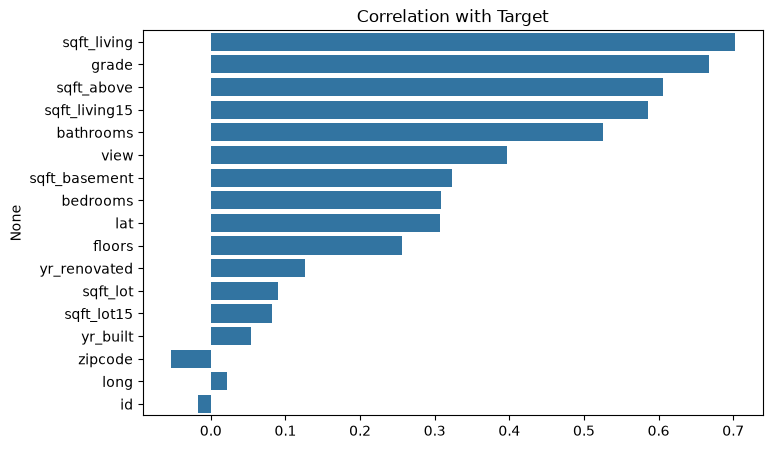

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
zipcode         -0.053203
long             0.021626
id              -0.016762
Name: price, dtype: float64

In [9]:
# Correlation with the Target
target_corr = (corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False))

plt.figure(figsize=(8,5))

sns.barplot(x = target_corr.values, y = target_corr.index)

plt.title("Correlation with Target")
plt.show()

target_corr

In [12]:
# Mutual Information -> Clasificación

X_num = X.select_dtypes(exclude="object")

mi_scores = mutual_info_classif(X_num,y,random_state = 1)

mi_df = pd.DataFrame({"feature": X_num.columns, "mi_score": mi_scores})

mi_df = mi_df.sort_values("mi_score",ascending=False)

mi_df.head(20)

,feature,mi_score
7,grade,0.557807
5,floors,0.467018
1,bedrooms,0.334273
13,lat,0.333322
3,sqft_living,0.323650
2,bathrooms,0.261108
15,sqft_living15,0.250045
12,zipcode,0.237065
8,sqft_above,0.211127
14,long,0.078021


In [13]:
# Regresión
mi_scores = mutual_info_regression(X_num,y,random_state = 1)

mi_df = pd.DataFrame({"feature": X_num.columns, "mi_score": mi_scores})

mi_df = mi_df.sort_values("mi_score", ascending = False)

mi_df.head(20)

,feature,mi_score
12,zipcode,0.418354
3,sqft_living,0.353818
7,grade,0.345976
13,lat,0.341137
15,sqft_living15,0.269784
8,sqft_above,0.260481
2,bathrooms,0.203515
14,long,0.118223
0,id,0.108904
16,sqft_lot15,0.082342


In [24]:
# Feature Importance con Random Forest -> Clasificación
rf = RandomForestClassifier(n_estimators = 10, random_state = 1, n_jobs = -1)

rf.fit(X_num, y)

importance_df = pd.DataFrame({ "feature": X_num.columns, "importance": rf.feature_importances_})

importance_df = importance_df.sort_values("importance", ascending = False)

importance_df.head(20)

,feature,importance
13,lat,0.097742
0,id,0.090625
4,sqft_lot,0.089890
15,sqft_living15,0.088327
14,long,0.087299
16,sqft_lot15,0.087229
3,sqft_living,0.083024
8,sqft_above,0.080746
10,yr_built,0.077246
12,zipcode,0.050867


In [14]:
# Regresión
rf = RandomForestRegressor(n_estimators = 300, random_state = 1, n_jobs = -1)

rf.fit(X_num, y)

importance_df = pd.DataFrame({"feature": X_num.columns, "importance": rf.feature_importances_})

importance_df = importance_df.sort_values( "importance", ascending = False )

importance_df.head(20)

,feature,importance
7,grade,0.325281
3,sqft_living,0.261462
13,lat,0.161284
14,long,0.070263
15,sqft_living15,0.031455
6,view,0.026557
10,yr_built,0.026462
8,sqft_above,0.022082
16,sqft_lot15,0.014702
4,sqft_lot,0.014377


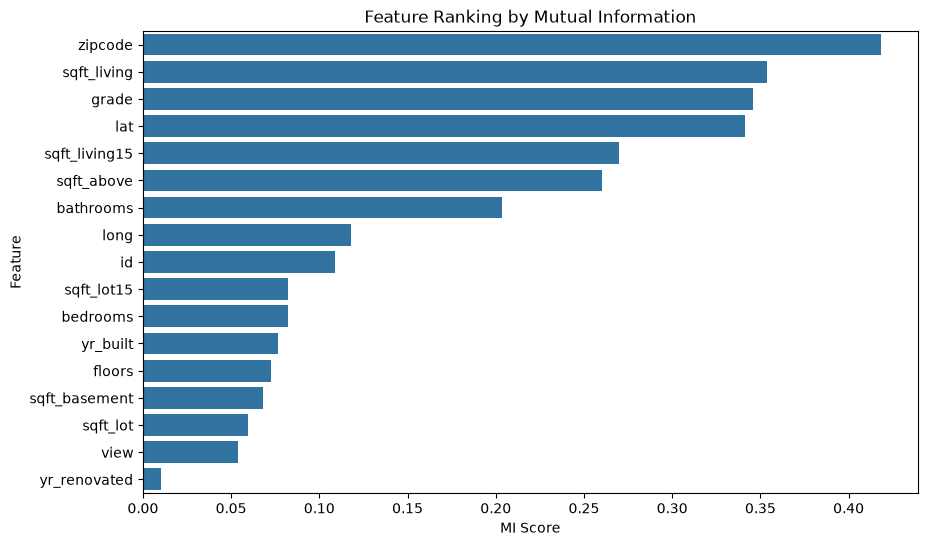

In [16]:
# Ranking de Features por Mutual Information
plt.figure(figsize=(10,6))

sns.barplot( data=mi_df, x="mi_score", y="feature")

plt.title("Feature Ranking by Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")

plt.show()

In [17]:
# Comparación MI vs Random Forest
comparison = (
    mi_df.merge(importance_df, on = "feature")
)

comparison = comparison.sort_values( "mi_score", ascending=False )

comparison.head(20)

,feature,mi_score,importance
0,zipcode,0.418354,0.013761
1,sqft_living,0.353818,0.261462
2,grade,0.345976,0.325281
3,lat,0.341137,0.161284
4,sqft_living15,0.269784,0.031455
5,sqft_above,0.260481,0.022082
6,bathrooms,0.203515,0.007795
7,long,0.118223,0.070263
8,id,0.108904,0.011299
9,sqft_lot15,0.082342,0.014702


In [18]:
# Features con Baja Relevancia
LOW_MI_THRESHOLD = 0.01

low_signal_features = mi_df[ mi_df["mi_score"] < LOW_MI_THRESHOLD ]

print("Features candidatas a eliminar:")
display(low_signal_features)

Features candidatas a eliminar:


,feature,mi_score


In [25]:
# Conclusión
print("""
Checklist antes de Feature Engineering:

    Variables altamente correlacionadas detectadas
    Features con baja Mutual Information identificadas
    Ranking de importancia calculado
    Variables irrelevantes marcadas para eliminación

Siguiente paso:
      
    Construir nuevas variables únicamente sobre las
    features que muestran señal predictiva.
""")


Checklist antes de Feature Engineering:

    Variables altamente correlacionadas detectadas
    Features con baja Mutual Information identificadas
    Ranking de importancia calculado
    Variables irrelevantes marcadas para eliminación

Siguiente paso:

    Construir nuevas variables únicamente sobre las
    features que muestran señal predictiva.



Recomendaciones finales
-    Eliminar features con MI ≈ 0.
-    Revisar variables redundantes (correlación > 0.9).
-    Priorizar variables con alta importancia en Random Forest.
-    Evitar crear nuevas variables sobre features sin señal.
-    Realizar Feature Engineering solo después de esta fase de descubrimiento.